<a href="https://colab.research.google.com/github/Adheeshana/FIVORA/blob/Fabric-classification-experiments/Image_Classification_model_exp01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Install & Import Libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow version: {tf.__version__}")
print("GPU Available: ", tf.config.list_physical_devices('GPU'))

In [ ]:
# Cell 2: Mount Google Drive
import os
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    # Path updated to match your specific Drive structure
    BASE_PATH = '/content/drive/MyDrive/Fivora/fabric_project/Fabric_Type_ Dataset'
    TRAIN_PATH = os.path.join(BASE_PATH, 'train')
    TEST_PATH = os.path.join(BASE_PATH, 'test')
    DATASET_PATH = TRAIN_PATH
    print(f"Drive mounted. Dataset path set to: {TRAIN_PATH}")
except Exception as e:
    print(f"Drive mount failed: {e}")
    print("Falling back to local directory.")
    TRAIN_PATH = '/content/fabric_dataset/train'
    TEST_PATH = '/content/fabric_dataset/test'

Mounted at /content/drive
Drive mounted. Dataset path set to: /content/drive/MyDrive/Fivora/fabric_project/Fabric_Type_ Dataset/train


In [ ]:
# Cell 3: Load Dataset
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load training and validation sets from the 'train' directory
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load test set from the 'test' directory
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(f"Class names: {class_names}")

Found 8281 files belonging to 9 classes.
Using 6625 files for training.
Found 8281 files belonging to 9 classes.
Using 1656 files for validation.
Found 920 files belonging to 9 classes.
Class names: ['Chiffon', 'Cotton_', 'Denim', 'Linen', 'Polyester', 'Silk', 'Velvet', 'Viscose', 'Wool']


In [ ]:
# Cell 4: Data Preprocessing & Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
    layers.RandomBrightness(0.1)
])

# Rescaling layer for normalization
rescale = layers.Rescaling(1./255)

In [ ]:
# Cell 5: Create Data Loaders / Generators
# Apply prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE).prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.map(lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE).prefetch(buffer_size=AUTOTUNE)

In [ ]:
num_classes = len(class_names)

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.GlobalAveragePooling2D(), # Replaced Flatten()
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,817 (436.79 KB)

 Trainable params: 111,369 (435.04 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Cell 7: Compile Model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [ ]:
# Cell 8: Train Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

EPOCHS = 50 # Increased EPOCHS

# Callbacks for smart training
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr] # Added callbacks
)

# Plot results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend(); plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss')
plt.show()

Epoch 1/50
 26/208 ━━━━━━━━━━━━━━━━━━━━ 27:18 9s/step - accuracy: 0.7798 - loss: 0.7020

KeyboardInterrupt: 

In [ ]:
# Cell 9: Evaluate Model
import tensorflow as tf # Ensure TensorFlow is available for model loading

# Ensure loaded_model is defined in case Cell 3abad456 was skipped or failed.
# This check prevents re-loading if it's already defined.
if 'loaded_model' not in locals():
    LOAD_PATH = '/content/drive/MyDrive/Fivora/Classification_model/fabric_classification_model_v2.h5'
    if tf.io.gfile.exists(LOAD_PATH):
        loaded_model = tf.keras.models.load_model(LOAD_PATH)
        print(f"DEBUG: Model loaded within evaluation cell for prediction from {LOAD_PATH}")
    else:
        print(f"Error: Model not found at {LOAD_PATH}. Please ensure model is saved and Cell 3abad456 runs successfully.")
        raise FileNotFoundError(f"Model not found at {LOAD_PATH}")

# Prepare the test dataset
test_ds = test_ds.map(lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE).prefetch(buffer_size=AUTOTUNE)

y_true = []
y_pred = []

print("Evaluating on test set...")
for x, y in test_ds:
    y_true.extend(y.numpy())
    # Use loaded_model instead of model for prediction
    preds = loaded_model.predict(x, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

DEBUG: Model loaded within evaluation cell for prediction from /content/drive/MyDrive/Fivora/Classification_model/fabric_classification_model_v2.h5
Evaluating on test set...


In [ ]:
import tensorflow as tf

# Cell X: Load the saved model
LOAD_PATH = '/content/drive/MyDrive/Fivora/Classification_model/fabric_classification_model_v2.h5'

if tf.io.gfile.exists(LOAD_PATH):
    loaded_model = tf.keras.models.load_model(LOAD_PATH)
    print(f"Model loaded successfully from {LOAD_PATH}")
    # You can now use loaded_model for predictions or further evaluation
    # For example, to print summary:
    loaded_model.summary()
else:
    print(f"Error: Model not found at {LOAD_PATH}")
    print("Please ensure the model was saved correctly and the path is accurate.")

After loading the model, you can replace `model` with `loaded_model` in subsequent prediction or evaluation cells if you wish to use the pre-trained version without retraining. For example, you could modify Cell 9 to use `loaded_model.predict(x, verbose=0)`.

In [ ]:
def predict_fabric(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) / 255.0

    predictions = model.predict(img_array, verbose=0)
    score = np.max(predictions)
    label = class_names[np.argmax(predictions)]

    plt.imshow(img)
    plt.title(f"Pred: {label} ({score:.2%})")
    plt.axis('off')
    plt.show()
    return label, score

In [ ]:
# Cell X: Find a sample image path from the test set
import os
import random

# Ensure TEST_PATH is defined (it should be from Cell 2)
if 'TEST_PATH' not in locals():
    print("Error: TEST_PATH is not defined. Please run Cell 2 first.")
else:
    print(f"Searching for sample image in: {TEST_PATH}")
    class_dirs = [d for d in os.listdir(TEST_PATH) if os.path.isdir(os.path.join(TEST_PATH, d))]
    if class_dirs:
        # Select a random class directory
        random_class_dir = random.choice(class_dirs)
        class_path = os.path.join(TEST_PATH, random_class_dir)
        image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
        if image_files:
            # Select a random image from that class
            sample_img_path = os.path.join(class_path, random.choice(image_files))
            print(f"Found new sample image: {sample_img_path}")
        else:
            sample_img_path = None
            print(f"No image files found in {class_path}")
    else:
        sample_img_path = None
        print(f"No class directories found in {TEST_PATH}")

# This variable will be used by the subsequent cell.


Searching for sample image in: /content/drive/MyDrive/Fivora/fabric_project/Fabric_Type_ Dataset/test
Found new sample image: /content/drive/MyDrive/Fivora/fabric_project/Fabric_Type_ Dataset/test/Denim/Denim_Aug_376.jpg


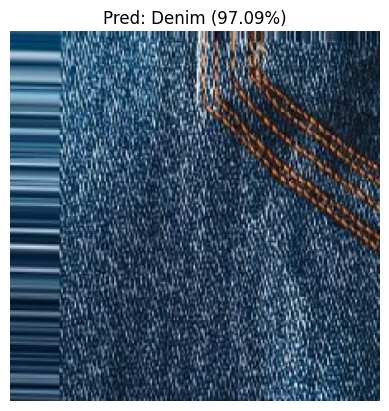

In [ ]:
# Cell 12: Test Prediction
# Replace with a path to a real image file to test
# Using the dynamically found sample_img_path from the previous cell.
if 'sample_img_path' in locals() and sample_img_path is not None and os.path.exists(sample_img_path):
    predict_fabric(sample_img_path)
else:
    print("Please provide a valid path to a sample image for testing or ensure previous cell ran successfully.")


In [ ]:
import os
# Cell 10: Save Model
SAVE_DIR = '/content/drive/MyDrive/Fivora/Classification_model'
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)
SAVE_PATH = os.path.join(SAVE_DIR, 'fabric_classification_model_v2.h5')
model.save(SAVE_PATH)
print(f"Model saved to {SAVE_PATH}")

Model saved to /content/drive/MyDrive/Fivora/Classification_model/fabric_classification_model_v2.h5
